#### Run the following only during the first time running the whole jupiter notebook

In [1]:
import os
import sys
current_dir = os.path.dirname(os.getcwd())
if not current_dir in sys.path:
    sys.path.append(current_dir)


# ----------------------------------------------------

In [2]:
import torch
import sequence
import numba as nb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from simulate.kernels import cpu_non_selective, cpu_relaxation, cpu_spatial_selective

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


# Selected Metrics

In [ ]:
# Myelin
t1_myelin = 0.226
t2_myelin = 300 * 1e-6
# -----------------
t1_myelin_max = 0.367
t1_myelin_min = 0.226


# White matter
t1_wm = 0.8
t2_wm = 0.08
# -----------------
t1_wm_max = 1.11
t1_wm_min = 0.75



# Time Step
dt = 10 # unite: us

# Off-resonance frequencies
df = np.linspace(-500, 500, 200)

M = (256,256, 200, 150,3) 


# 1. Inversion Recovery

In [4]:
non_selective_dt = dt*1e-6

pulse = sequence.rf.hyperbolic_secant(1500, mu=5, bandwidth=2400, dt=dt)
optimal_amplitude = pulse.get_optimal_amplitude(torch.pi)
pulse.amplitude = optimal_amplitude
print('Optimal Amplitude:', optimal_amplitude)
rf = pulse.waveform
rf = rf.detach().cpu().numpy().astype(np.complex128)

initial_magnetisation = np.array([0.0, 0.0, 1.0])

print(rf)


# white matter
magnetisation_wm_rf = cpu_non_selective(t1_wm, t2_wm, non_selective_dt, df, rf, initial_magnetisation)
print(magnetisation_wm_rf.shape)

# myelin
magnetisation_myelin_rf = cpu_non_selective(t1_myelin, t2_myelin, non_selective_dt, df, rf, initial_magnetisation)
print(magnetisation_myelin_rf.shape)

Optimal Amplitude: tensor(1.9971e-05)
[ 1.16521405e-05+7.13704480e-07j  1.17294512e-05+1.43760792e-06j
  1.17629907e-05+2.16888134e-06j  1.17524569e-05+2.90468006e-06j
  1.16977471e-05+3.64215907e-06j  1.15989687e-05+4.37848848e-06j
  1.14564327e-05+5.11087364e-06j  1.12706448e-05+5.83656492e-06j
  1.10423061e-05+6.55287658e-06j  1.07723044e-05+7.25719792e-06j
  1.04617038e-05+7.94701100e-06j  1.01117457e-05+8.61990338e-06j
  9.72382531e-06+9.27357542e-06j  9.29949056e-06+9.90585522e-06j
  8.84042765e-06+1.05147137e-05j  8.34845105e-06+1.10982592e-05j
  7.82548796e-06+1.16547662e-05j  7.27356610e-06+1.21826624e-05j
  6.69479732e-06+1.26805498e-05j  6.09138078e-06+1.31471961e-05j
  5.46555884e-06+1.35815535e-05j  4.81962479e-06+1.39827425e-05j
  4.15590694e-06+1.43500711e-05j  3.47675109e-06+1.46830216e-05j
  2.78450216e-06+1.49812568e-05j  2.08150345e-06+1.52446100e-05j
  1.37006407e-06+1.54730951e-05j  6.52473091e-07+1.56668830e-05j
 -6.90334119e-08+1.58263101e-05j -7.92273283e-07+1.5

### a. Inversion in Mz

<Figure size 600x400 with 0 Axes>

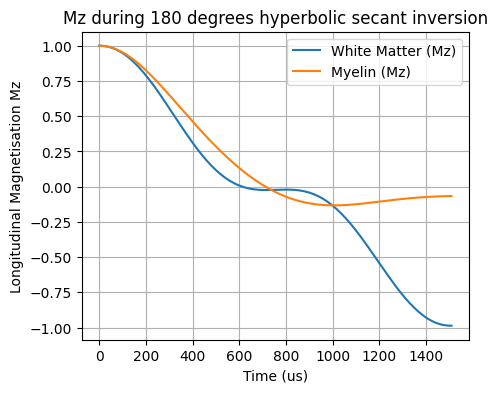

In [8]:
n_steps = magnetisation_wm_rf.shape[1] - 1
time = np.arange(n_steps + 1) * non_selective_dt * 1e6  # microseconds
plt.figure(figsize=(6,4))
plt.figure(figsize=(5,4))
plt.plot(time, magnetisation_wm_rf[100, :, 2], label='White Matter (Mz)')
plt.plot(time, magnetisation_myelin_rf[100, :, 2], label='Myelin (Mz)')
plt.xlabel('Time (us)')
plt.ylabel('Longitudinal Magnetisation Mz')
plt.title('Mz during 180 degrees hyperbolic secant inversion')
plt.grid(True)
plt.legend()
plt.show()


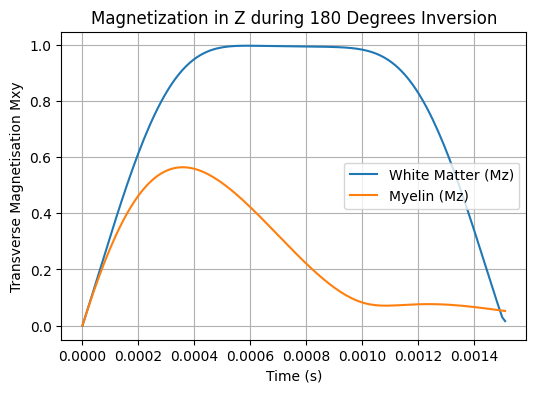

In [96]:
n_steps = magnetisation_wm_rf.shape[1] - 1
time = np.arange(n_steps + 1) * non_selective_dt  # seconds
plt.figure(figsize=(6,4))
plt.plot(time, np.sqrt(magnetisation_wm_rf[100, :, 0]**2 + magnetisation_wm_rf[100, :, 1]**2), label='White Matter (Mz)')
plt.plot(time, np.sqrt(magnetisation_myelin_rf[100, :, 0]**2 + magnetisation_myelin_rf[100, :, 1]**2), label='Myelin (Mz)')
plt.xlabel('Time (s)')
plt.ylabel('Transverse Magnetisation Mxy')
plt.title('Magnetization in Z during 180 Degrees Inversion')
plt.grid(True)
plt.legend()
plt.show()


### b. Inversion Efficiency of WM and Myelin in Z across Offset Frequencies

<Figure size 600x400 with 0 Axes>

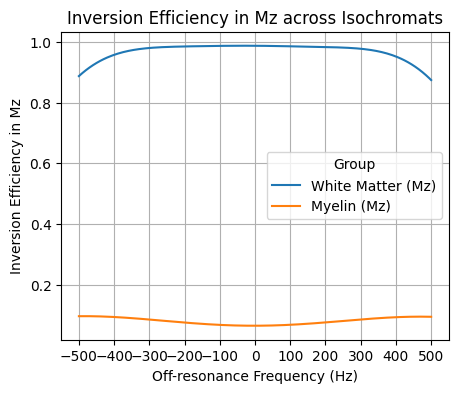

         Max   Min  Difference
WM      0.99  0.87        0.12
Myelin  0.10  0.07        0.03


In [10]:
n_steps = magnetisation_wm_rf.shape[1] - 1
time = np.arange(n_steps + 1) * non_selective_dt  # seconds
Mz_offres_wm = magnetisation_wm_rf[:, -1, 2] * (-1)
Mz_offres_myelin = magnetisation_myelin_rf[:, -1, 2] * (-1)
plt.figure(figsize=(6,4))
plt.figure(figsize=(5,4))
plt.plot(df, Mz_offres_wm, label='White Matter (Mz)')
plt.plot(df, Mz_offres_myelin, label='Myelin (Mz)')
plt.xlabel('Off-resonance Frequency (Hz)')
plt.ylabel('Inversion Efficiency in Mz')
plt.xticks(np.linspace(-500, 500, 11))
plt.title('Inversion Efficiency in Mz across Isochromats')
plt.grid(True)
plt.legend(title='Group')
plt.show()

max_inverse_wm = round(max(Mz_offres_wm),2)
min_inverse_wm = round(min(Mz_offres_wm),2)
diff_inverse_wm = round(max_inverse_wm - min_inverse_wm, 2)

max_inverse_myelin = round(max(Mz_offres_myelin),2)
min_inverse_myelin = round(min(Mz_offres_myelin),2)
diff_inverse_myelin = round(max_inverse_myelin - min_inverse_myelin, 2)

table = pd.DataFrame({
    'Max': [max_inverse_wm, max_inverse_myelin],
    'Min': [min_inverse_wm, min_inverse_myelin],
    'Difference': [diff_inverse_wm, diff_inverse_myelin]
}, index=['WM', 'Myelin'])

print(table)


### c. Inversion Recovery

In [11]:
zero_padding = int(4.5/non_selective_dt)
rf_with_padding = np.pad(rf, (0, zero_padding))
print('Number of zero paddings:', zero_padding)

# white matter
magnetisation_wm_rf_with_padding = cpu_non_selective(t1_wm, t2_wm, non_selective_dt, df, rf_with_padding, initial_magnetisation)
print(magnetisation_wm_rf_with_padding.shape)

# myelin
magnetisation_myelin_rf_with_padding = cpu_non_selective(t1_myelin, t2_myelin, non_selective_dt, df, rf_with_padding, initial_magnetisation)
print(magnetisation_myelin_rf_with_padding.shape)


Number of zero paddings: 450000
(200, 450152, 3)
(200, 450152, 3)


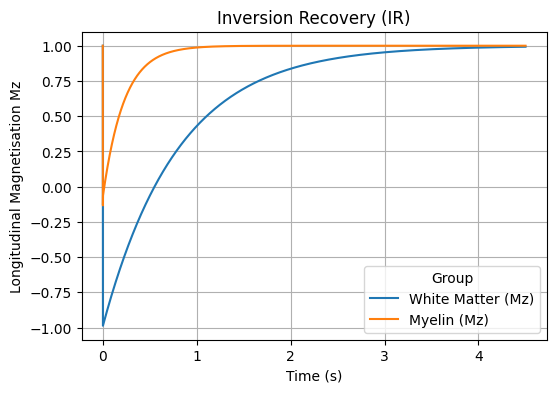

In [12]:
n_steps = magnetisation_wm_rf_with_padding.shape[1] -1
time = np.arange(n_steps + 1) * non_selective_dt  # seconds
plt.figure(figsize=(6,4))
plt.plot(time, magnetisation_wm_rf_with_padding[100, :, 2], label='White Matter (Mz)')
plt.plot(time, magnetisation_myelin_rf_with_padding[100, :, 2], label='Myelin (Mz)')
plt.xlabel('Time (s)')
plt.ylabel('Longitudinal Magnetisation Mz')
plt.title('Inversion Recovery (IR)')
plt.grid(True)
plt.legend(title='Group')
plt.show()


### d. Inversion Recovery with T1 Fan Chart

In [13]:
zero_padding = int(4.5/non_selective_dt)
rf_with_padding = np.pad(rf, (0, zero_padding))
print('Number of zero paddings:', zero_padding)

# white matter
magnetisation_wm_rf_with_padding_maxT1 = cpu_non_selective(t1_wm_max, t2_wm, non_selective_dt, df, rf_with_padding, initial_magnetisation)
magnetisation_wm_rf_with_padding_minT1 = cpu_non_selective(t1_wm_min, t2_wm, non_selective_dt, df, rf_with_padding, initial_magnetisation)


# myelin
magnetisation_myelin_rf_with_padding_maxT1 = cpu_non_selective(t1_myelin_max, t2_myelin, non_selective_dt, df, rf_with_padding, initial_magnetisation)
magnetisation_myelin_rf_with_padding_minT1 = cpu_non_selective(t1_myelin_min, t2_myelin, non_selective_dt, df, rf_with_padding, initial_magnetisation)


Number of zero paddings: 450000


70634
47770


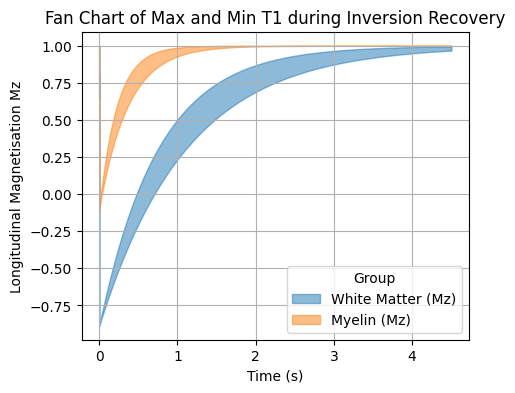

In [14]:
n_steps = magnetisation_wm_rf_with_padding.shape[1] - 1
time = np.arange(n_steps + 1) * non_selective_dt  # seconds
plt.figure(figsize=(5,4))
print(np.argmin(np.abs(magnetisation_wm_rf_with_padding_maxT1[0, :, 2])))
print(np.argmin(np.abs(magnetisation_wm_rf_with_padding_minT1[0, :, 2])))
plt.fill_between(time, magnetisation_wm_rf_with_padding_maxT1[0, :, 2], magnetisation_wm_rf_with_padding_minT1[0, :, 2], alpha = 0.5, color = 'tab:blue', label='White Matter (Mz)')
plt.fill_between(time, magnetisation_myelin_rf_with_padding_maxT1[0, :, 2], magnetisation_myelin_rf_with_padding_minT1[0, :, 2], alpha = 0.5, color = 'tab:orange', label='Myelin (Mz)')

plt.xlabel('Time (s)')
plt.ylabel('Longitudinal Magnetisation Mz')
plt.title('Fan Chart of Max and Min T1 during Inversion Recovery')
plt.grid(True)
plt.legend(title='Group')
plt.show()


# 1.5 90 Degrees Excitation

### (1) The Myelin Signals in xy

In [15]:
n_inversion_steps = rf.shape[0]
array_wm = magnetisation_wm_rf_with_padding[100, n_inversion_steps + 1 :, 2]
idx = np.argmin(np.abs(array_wm))
print(idx)
n_nullout_step = n_inversion_steps + idx + 1
print(n_nullout_step) # Null out WM at: 0.55 s



t_nullout = n_nullout_step * dt
print(magnetisation_myelin_rf_with_padding[:, n_nullout_step, :])

54914
55066
[[ 3.95252517e-323  7.41098469e-323  9.03373528e-001]
 [-7.41098469e-323  7.41098469e-323  9.03368643e-001]
 [-7.41098469e-323  6.91691904e-323  9.03365742e-001]
 [-7.41098469e-323 -4.44659081e-323  9.03364794e-001]
 [-7.41098469e-323 -7.41098469e-323  9.03365769e-001]
 [ 1.97626258e-323 -7.41098469e-323  9.03368634e-001]
 [ 7.41098469e-323 -7.41098469e-323  9.03373356e-001]
 [ 7.41098469e-323 -4.94065646e-323  9.03379901e-001]
 [ 7.41098469e-323  7.41098469e-323  9.03388235e-001]
 [ 5.43472210e-323  7.41098469e-323  9.03398323e-001]
 [-5.92878775e-323  7.41098469e-323  9.03410127e-001]
 [-7.41098469e-323  7.41098469e-323  9.03423611e-001]
 [-7.41098469e-323 -1.48219694e-323  9.03438737e-001]
 [-7.41098469e-323 -7.41098469e-323  9.03455466e-001]
 [-3.95252517e-323 -7.41098469e-323  9.03473759e-001]
 [ 7.41098469e-323 -7.41098469e-323  9.03493577e-001]
 [ 7.41098469e-323 -4.44659081e-323  9.03514877e-001]
 [ 7.41098469e-323  7.41098469e-323  9.03537621e-001]
 [ 7.41098469e-3

# 2. 90 Degrees Excitation

##### When does WM in Z get nulled out?

In [55]:
n_inversion_steps = rf.shape[0]
array_wm = magnetisation_wm_rf_with_padding[100, n_inversion_steps + 1 :, 2]
print(array_wm)
print(len(array_wm))
idx = np.argmin(np.abs(array_wm))
print(idx)


n_nullout_step = n_inversion_steps + idx + 1
print(n_nullout_step) # Null out WM at: 0.55 s
t_nullout = n_nullout_step * dt
print(magnetisation_myelin_rf_with_padding[100, n_nullout_step, :])

[-0.98659694 -0.9865721  -0.98654727 ...  0.99283494  0.99283503
  0.99283512]
450000
54914
55066
[-7.410985e-323 -7.410985e-323  9.061466e-001]


### (1) Sinc RF

zero_padding: 33
rf_sinc.shape: (48,)
(200, 82, 3)
(200, 82)
47


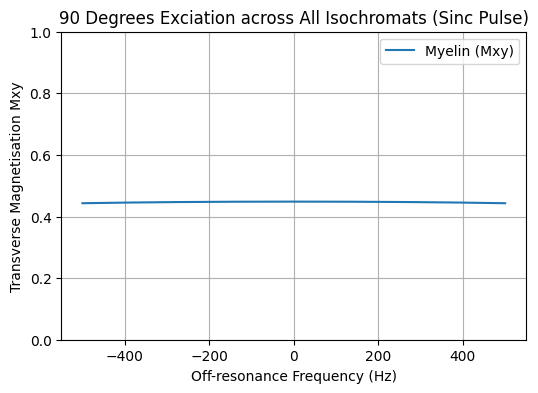

In [ ]:
duration_sinc = 470
bw_sinc = 2700
dt_rect = 2

pulse_rect = sequence.rf.hamming_sinc(duration_sinc, bw_sincdt = dt_rect)
optimal_amplitude_rect = pulse_rect.get_optimal_amplitude(torch.pi/2)
pulse_rect.amplitude = optimal_amplitude_rect
#pulse_rect.display()
rf_rect = pulse_rect.waveform
rf_rect = rf_rect.detach().cpu().numpy().astype(np.complex128)
#print('optimal:', optimal_amplitude_rect)



# WM
initial_magnetisation_wm_rect = magnetisation_wm_rf_with_padding[100, n_nullout_step, :]
#print('initial_magnetisation_wm_rect:', n_nullout_step,initial_magnetisation_wm_rect)

# Myelin
initial_magnetisation_myelin_rect = magnetisation_myelin_rf_with_padding[100, n_nullout_step, :]
#print('initial_magnetisation_myelin_rect:', n_nullout_step,initial_magnetisation_myelin_rect)

# Add padding for transverse recovery
zero_padding = int((800-duration_rect)/dt_rect)
print('zero_padding:',zero_padding)
print('rf_rect.shape:', rf_rect.shape)
pulse_rect_with_padding = np.pad(rf_rect, (0, zero_padding))

magnetisation_wm_rf_rect = cpu_non_selective(t1_wm, t2_wm, non_selective_dt, df, pulse_rect_with_padding, initial_magnetisation_wm_rect)
print(magnetisation_wm_rf_rect.shape)
magnetisation_myelin_rf_rect = cpu_non_selective(t1_myelin, t2_myelin, non_selective_dt, df, pulse_rect_with_padding, initial_magnetisation_myelin_rect)
#print('magnetisation_wm_rf_rect:', magnetisation_wm_rf_rect[100,-1,:])
#print('magnetisation_myelin_rf_rect:', magnetisation_myelin_rf_rect[100,-1,:])



n_steps =  magnetisation_myelin_rf_rect.shape[1]


time = np.arange(n_steps) * dt_rect  # micro seconds
Mxy_rect_wm = np.sqrt(
    magnetisation_wm_rf_rect[:, :, 0]**2 +
    magnetisation_wm_rf_rect[:, :, 1]**2
)
Mxy_rect_myelin = np.sqrt(
    magnetisation_myelin_rf_rect[:, :, 0]**2 +
    magnetisation_myelin_rf_rect[:, :, 1]**2
)
print(Mxy_rect_wm.shape)
t_readout_rect = int((duration_rect + 7)/dt_rect)
print(t_readout_rect)



plt.figure(figsize=(6,4))
#plt.plot(df,  Mxy_rect_wm[:, t_readout_rect], label='White Matter (Mxy)')
plt.plot(df, Mxy_rect_myelin[:, t_readout_rect], label='Myelin (Mxy)')
plt.xlabel('Off-resonance Frequency (Hz)')
plt.ylabel('Transverse Magnetisation Mxy')
plt.ylim([0,1])
plt.title('90 Degrees Exciation across All Isochromats (Rect Pulse)')
plt.grid(True)
plt.legend()
plt.show()


## (1) Sinc RF

477


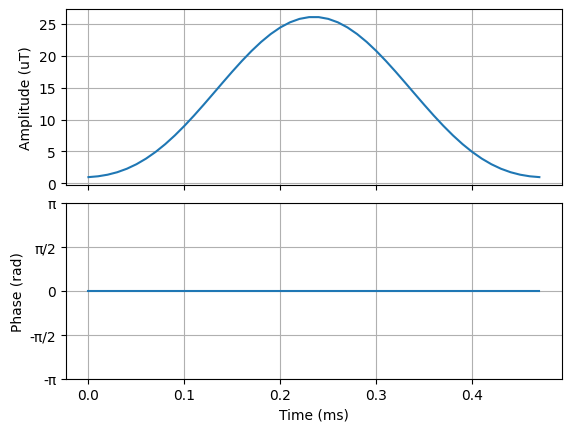

optimal: tensor(2.6082e-05)
initial_magnetisation_wm_sinc: 55066 [-6.93085953e-06  1.59023324e-05  1.90716504e-06]
initial_magnetisation_myelin_sinc: 55066 [-7.410985e-323 -7.410985e-323  9.061466e-001]
zero_padding: 73
(200, 122, 3)
magnetisation_wm_rf_sinc: [-1.22510739e-05  3.56217446e-04  1.23196538e-03]
magnetisation_myelin_rf_sinc: [-0.00058554  0.0380949   0.20417033]


In [ ]:
duration_sinc = 470
bw_sinc = 2700
dt_sinc = 10
tx_rx = 7
t_b4readout_sinc = duration_sinc + tx_rx
print(t_b4readout_sinc)
pulse_sinc = sequence.rf.hamming_sinc(duration_sinc, bw_sinc, dt = dt_sinc)
optimal_amplitude_sinc = pulse_sinc.get_optimal_amplitude(torch.pi/2)
pulse_sinc.amplitude = optimal_amplitude_sinc
pulse_sinc.display()
rf_sinc = pulse_sinc.waveform
rf_sinc = rf_sinc.detach().cpu().numpy().astype(np.complex128)
print('optimal:', optimal_amplitude_sinc)



# WM
initial_magnetisation_wm_sinc = magnetisation_wm_rf_with_padding[100, n_nullout_step, :]
print('initial_magnetisation_wm_sinc:', n_nullout_step,initial_magnetisation_wm_sinc)

# Myelin
initial_magnetisation_myelin_sinc = magnetisation_myelin_rf_with_padding[100, n_nullout_step, :]
print('initial_magnetisation_myelin_sinc:', n_nullout_step,initial_magnetisation_myelin_sinc)

# Add padding for transverse recovery
zero_padding = int((1200-duration_sinc)/dt_sinc)
print('zero_padding:',zero_padding)
pulse_sinc_with_padding = np.pad(rf_sinc, (0, zero_padding))

magnetisation_wm_rf_sinc = cpu_non_selective(t1_wm, t2_wm, non_selective_dt, df, pulse_sinc_with_padding, initial_magnetisation_wm_sinc)
print(magnetisation_wm_rf_sinc.shape)
magnetisation_myelin_rf_sinc = cpu_non_selective(t1_myelin, t2_myelin, non_selective_dt, df, pulse_sinc_with_padding,  initial_magnetisation_myelin_sinc)
print('magnetisation_wm_rf_sinc:', magnetisation_wm_rf_sinc[100,-1,:])
print('magnetisation_myelin_rf_sinc:', magnetisation_myelin_rf_sinc[100,-1,:])




477


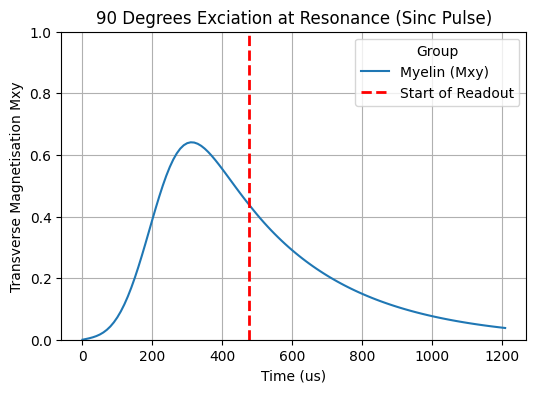

In [82]:

n_steps =  magnetisation_myelin_rf_sinc.shape[1]


time = np.arange(n_steps) * dt  # micro seconds
# print(magnetisation_myelin_rf_with_padding.shape)
# print(magnetisation_myelin_rf_sinc.shape)
# magnetisation_wm_rf_total = np.concatenate([magnetisation_wm_rf_with_padding, magnetisation_wm_rf_sinc], axis=1)
# magnetisation_myelin_rf_total = np.concatenate([magnetisation_myelin_rf_with_padding, magnetisation_myelin_rf_sinc], axis=1)
# print(magnetisation_myelin_rf_total.shape)

magnetisation_wm_rf_total_xy = np.sqrt(np.power(magnetisation_wm_rf_sinc[100, :, 0], 2) + np.power(magnetisation_wm_rf_sinc[100, :, 1], 2))
magnetisation_myelin_rf_total_xy = np.sqrt(np.power(magnetisation_myelin_rf_sinc[100, :, 0], 2) + np.power(magnetisation_myelin_rf_sinc[100, :, 1], 2))
print(t_b4readout_sinc)
plt.figure(figsize=(6,4))
#plt.plot(time, magnetisation_wm_rf_total_xy, label='White Matter (Mxy)')
plt.plot(time, magnetisation_myelin_rf_total_xy, label='Myelin (Mxy)')

plt.axvline(x = t_b4readout_sinc, linestyle='--', linewidth=2, color = 'r', label = "Start of Readout")
plt.xlabel('Time (us)')
plt.ylabel('Transverse Magnetisation Mxy')
plt.ylim([0,1])
plt.title('90 Degrees Exciation at Resonance (Sinc Pulse)')
plt.grid(True)
plt.legend(title = "Group")
plt.show()

(200, 450152, 3)
(200, 82, 3)
(200, 450234, 3)


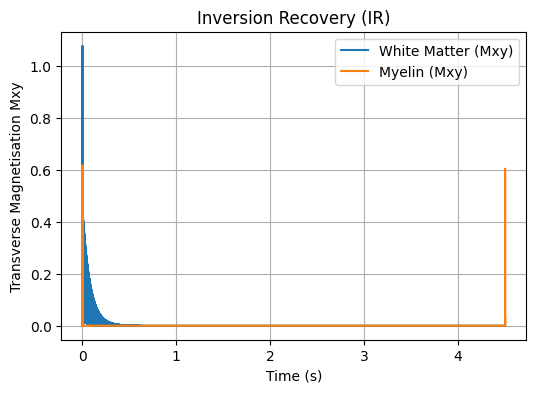

In [24]:
n_steps = magnetisation_myelin_rf_with_padding.shape[1] + magnetisation_myelin_rf_sinc.shape[1]


time = np.arange(n_steps) * non_selective_dt  # seconds
print(magnetisation_myelin_rf_with_padding.shape)
print(magnetisation_myelin_rf_sinc.shape)
magnetisation_wm_rf_total = np.concatenate([magnetisation_wm_rf_with_padding, magnetisation_wm_rf_sinc], axis=1)
magnetisation_myelin_rf_total = np.concatenate([magnetisation_myelin_rf_with_padding, magnetisation_myelin_rf_sinc], axis=1)
print(magnetisation_myelin_rf_total.shape)

magnetisation_wm_rf_total_xy = np.sqrt(np.power(magnetisation_wm_rf_total[100, :, 0], 2) + np.power(magnetisation_wm_rf_total[0, :, 1], 2))
magnetisation_myelin_rf_total_xy = np.sqrt(np.power(magnetisation_myelin_rf_total[100, :, 0], 2) + np.power(magnetisation_myelin_rf_total[0, :, 1], 2))


plt.figure(figsize=(6,4))
plt.plot(time, magnetisation_wm_rf_total_xy, label='White Matter (Mxy)')
plt.plot(time, magnetisation_myelin_rf_total_xy, label='Myelin (Mxy)')
plt.xlabel('Time (s)')
plt.ylabel('Transverse Magnetisation Mxy')
plt.title('Inversion Recovery (IR)')
plt.grid(True)
plt.legend()
plt.show()

### (2) Rect RF

zero_padding: 385
rf_rect.shape: (16,)
(200, 402, 3)
(200, 402)
18


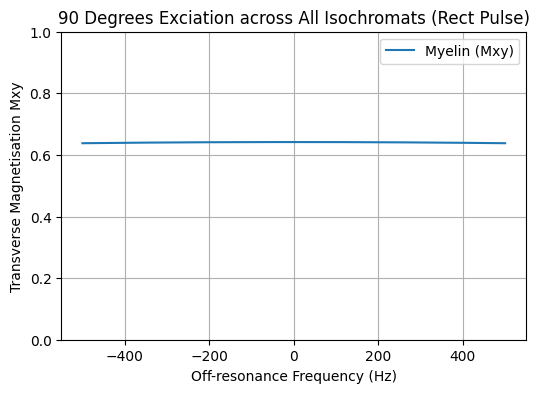

In [88]:
duration_rect = 30
dt_rect = 2

pulse_rect = sequence.rf.rect(duration_rect, dt = dt_rect)
optimal_amplitude_rect = pulse_rect.get_optimal_amplitude(torch.pi/2)
pulse_rect.amplitude = optimal_amplitude_rect
#pulse_rect.display()
rf_rect = pulse_rect.waveform
rf_rect = rf_rect.detach().cpu().numpy().astype(np.complex128)
#print('optimal:', optimal_amplitude_rect)



# WM
initial_magnetisation_wm_rect = magnetisation_wm_rf_with_padding[100, n_nullout_step, :]
#print('initial_magnetisation_wm_rect:', n_nullout_step,initial_magnetisation_wm_rect)

# Myelin
initial_magnetisation_myelin_rect = magnetisation_myelin_rf_with_padding[100, n_nullout_step, :]
#print('initial_magnetisation_myelin_rect:', n_nullout_step,initial_magnetisation_myelin_rect)

# Add padding for transverse recovery
zero_padding = int((800-duration_rect)/dt_rect)
print('zero_padding:',zero_padding)
print('rf_rect.shape:', rf_rect.shape)
pulse_rect_with_padding = np.pad(rf_rect, (0, zero_padding))

magnetisation_wm_rf_rect = cpu_non_selective(t1_wm, t2_wm, non_selective_dt, df, pulse_rect_with_padding, initial_magnetisation_wm_rect)
print(magnetisation_wm_rf_rect.shape)
magnetisation_myelin_rf_rect = cpu_non_selective(t1_myelin, t2_myelin, non_selective_dt, df, pulse_rect_with_padding, initial_magnetisation_myelin_rect)
#print('magnetisation_wm_rf_rect:', magnetisation_wm_rf_rect[100,-1,:])
#print('magnetisation_myelin_rf_rect:', magnetisation_myelin_rf_rect[100,-1,:])



n_steps =  magnetisation_myelin_rf_rect.shape[1]


time = np.arange(n_steps) * dt_rect  # micro seconds
Mxy_rect_wm = np.sqrt(
    magnetisation_wm_rf_rect[:, :, 0]**2 +
    magnetisation_wm_rf_rect[:, :, 1]**2
)
Mxy_rect_myelin = np.sqrt(
    magnetisation_myelin_rf_rect[:, :, 0]**2 +
    magnetisation_myelin_rf_rect[:, :, 1]**2
)
print(Mxy_rect_wm.shape)
t_readout_rect = int((duration_rect + 7)/dt_rect)
print(t_readout_rect)



plt.figure(figsize=(6,4))
#plt.plot(df,  Mxy_rect_wm[:, t_readout_rect], label='White Matter (Mxy)')
plt.plot(df, Mxy_rect_myelin[:, t_readout_rect], label='Myelin (Mxy)')
plt.xlabel('Off-resonance Frequency (Hz)')
plt.ylabel('Transverse Magnetisation Mxy')
plt.ylim([0,1])
plt.title('90 Degrees Exciation across All Isochromats (Rect Pulse)')
plt.grid(True)
plt.legend()
plt.show()


## (2) Rect RF

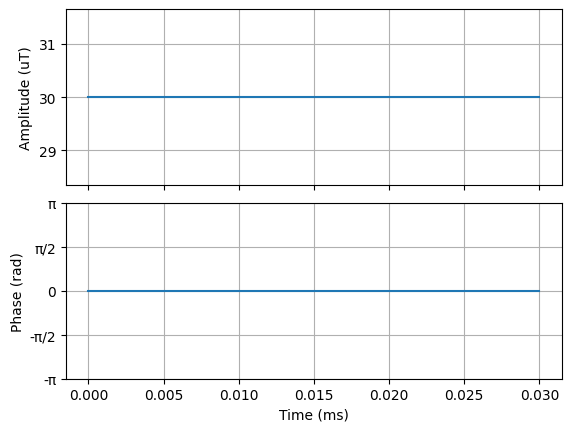

initial_magnetisation_wm_rect: 55065 [-6.92921506e-06  1.59054144e-05 -1.05928892e-05]
initial_magnetisation_myelin_rect: 55065 [-7.41098469e-323 -7.41098469e-323  9.06142447e-001]
magnetisation_wm_rf_rect: [-8.44164182e-06  1.10597930e-04  1.18841589e-03]
magnetisation_myelin_rf_rect: [-0.00059198  0.04034568  0.35715885]


In [80]:
duration_rect = 30
dt_rect = 2
tx_rx = 7
t_b4readout_rect = duration_rect + tx_rx


pulse_rect = sequence.rf.rect(duration_rect, dt = dt_rect)
optimal_amplitude_rect = pulse_rect.get_optimal_amplitude(torch.pi/2)
pulse_rect.amplitude = optimal_amplitude_rect
pulse_rect.display()
rf_rect = pulse_rect.waveform
rf_rect = rf_rect.detach().cpu().numpy().astype(np.complex128)



# WM
initial_magnetisation_wm_rect = magnetisation_wm_rf_with_padding[100, n_nullout_step - 1, :]
print('initial_magnetisation_wm_rect:', n_nullout_step - 1,initial_magnetisation_wm_rect)

# Myelin
initial_magnetisation_myelin_rect = magnetisation_myelin_rf_with_padding[100, n_nullout_step - 1, :]
print('initial_magnetisation_myelin_rect:', n_nullout_step - 1,initial_magnetisation_myelin_rect)

# Add padding for transverse recovery
zero_padding = int((200-duration_rect)/dt_rect)
pulse_rect_with_padding = np.pad(rf_rect, (0, zero_padding))

magnetisation_wm_rf_rect = cpu_non_selective(t1_wm, t2_wm, non_selective_dt, df, pulse_rect_with_padding, initial_magnetisation_wm_rect)
magnetisation_myelin_rf_rect = cpu_non_selective(t1_myelin, t2_myelin, non_selective_dt, df, pulse_rect_with_padding,  initial_magnetisation_myelin_rect)
print('magnetisation_wm_rf_rect:', magnetisation_wm_rf_rect[100,-1,:])
print('magnetisation_myelin_rf_rect:', magnetisation_myelin_rf_rect[100,-1,:])




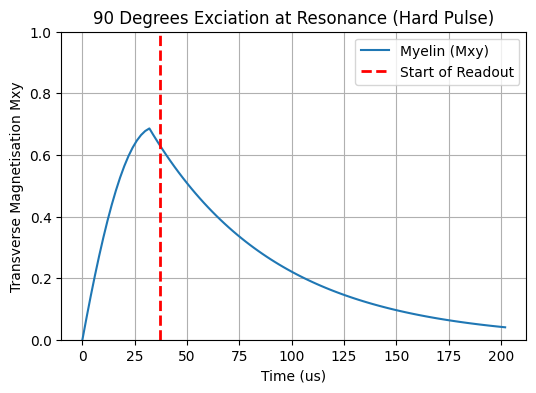

In [81]:
n_steps =  magnetisation_myelin_rf_rect.shape[1]


time = np.arange(n_steps) * dt_rect  # micro seconds

magnetisation_wm_rf_total_xy_rect = np.sqrt(np.power(magnetisation_wm_rf_rect[100, :, 0], 2) + np.power(magnetisation_wm_rf_rect[100, :, 1], 2))
magnetisation_myelin_rf_total_xy_rect = np.sqrt(np.power(magnetisation_myelin_rf_rect[100, :, 0], 2) + np.power(magnetisation_myelin_rf_rect[100, :, 1], 2))


plt.figure(figsize=(6,4))
#plt.plot(time, magnetisation_wm_rf_total_xy_rect, label='White Matter (Mxy)')
plt.plot(time, magnetisation_myelin_rf_total_xy_rect, label='Myelin (Mxy)')
plt.xlabel('Time (us)')
plt.ylim([0,1])
plt.ylabel('Transverse Magnetisation Mxy')
plt.axvline(x = t_b4readout_rect, linestyle='--', linewidth=2, color = 'r', label = "Start of Readout")
plt.title('90 Degrees Exciation at Resonance (Hard Pulse)')
plt.grid(True)
plt.legend()
plt.show()

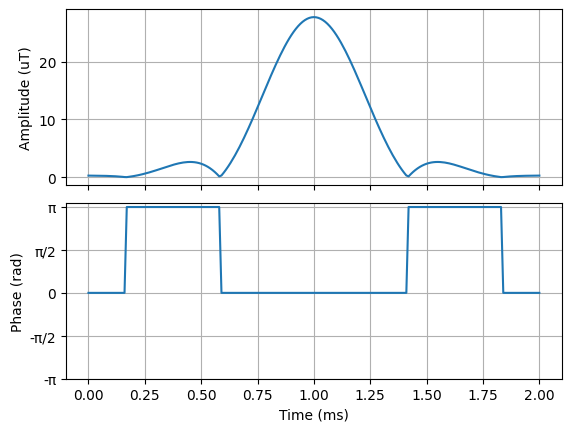

optimal_amplitude_sinc: tensor(2.7702e-05)
length: 201


TypeError: linspace() missing 1 required positional argument: 'stop'

In [ ]:
dt_sinc = 2000
bw_sinc = 2400

pulse_sinc = sequence.rf.hamming_sinc(dt_sinc, bw_sinc, dt = dt)
optimal_amplitude_sinc = pulse_sinc.get_optimal_amplitude(torch.pi)
pulse_sinc.amplitude = optimal_amplitude_sinc
pulse_sinc.display()
rf_sinc = pulse_sinc.waveform
rf_sinc = rf_sinc.detach().cpu().numpy().astype(np.complex128)
print('optimal_amplitude_sinc:', optimal_amplitude_sinc)
print('length:', len(rf_sinc))


selective_dt = dt*1e-6
isochromat_n = np.linspace([])
# WM
pos_wm = np.array(range(0, df.shape[0]))
pos_wm = magnetisation_wm_rf_with_padding[:, n_nullout_step - 1 , :].T
pos_wm = np.ascontiguousarray(pos_wm)
print('pos_wm.shape:',pos_wm.shape)
print(pos_wm[:,0])

gradient_rect_wm = sequence.gradient.rect(dt_sinc, 2, dt = dt)
initial_magnetisation_wm_sinc = magnetisation_wm_rf_with_padding[100, n_nullout_step - 1, :]

grad_wm_sinc = gradient_rect_wm.waveform.detach().cpu().numpy().astype(np.float64)
print('grad_wm_sinc.shape:', grad_wm_sinc.shape)
print(grad_wm_sinc[:,0])

# Myelin
pos_myelin = np.array(range(0, df.shape[0]))
pos_myelin = magnetisation_myelin_rf_with_padding[:, n_nullout_step - 1 , :].T
pos_myelin = np.ascontiguousarray(pos_myelin)
print('initial_magnetisation_wm_sinc:', n_nullout_step - 1,initial_magnetisation_wm_sinc)
print('pos_myelin.shape:',pos_myelin.shape)
#print(pos_myelin[:100])

gradient_rect_myelin = sequence.gradient.rect(dt_sinc, 2, dt = dt)
initial_magnetisation_myelin_sinc = magnetisation_myelin_rf_with_padding[100, n_nullout_step - 1, :]
print('initial_magnetisation_myelin_sinc:', n_nullout_step - 1,initial_magnetisation_myelin_sinc)
grad_myelin_sinc = gradient_rect_myelin.waveform.detach().cpu().numpy().astype(np.float64)
print('grad_sinc.shape:', grad_myelin_sinc.shape)
print(grad_myelin_sinc[:,0])

magnetisation_wm_rf_sinc = cpu_spatial_selective(t1_wm, t2_wm, selective_dt, pos_wm, rf_sinc, grad_wm_sinc, initial_magnetisation_wm_sinc) 
print('magnetisation_wm_rf_sinc:', magnetisation_wm_rf_sinc[100,-1,:])
magnetisation_myelin_rf_sinc = cpu_spatial_selective(t1_myelin, t2_myelin, selective_dt, pos_myelin, rf_sinc, grad_myelin_sinc, initial_magnetisation_myelin_sinc) 
print('magnetisation_myelin_rf_sinc:', magnetisation_myelin_rf_sinc[100,-1,:])

In [ ]:
n_steps = magnetisation_myelin_rf_with_padding.shape[1] + magnetisation_myelin_rf_sinc.shape[1]


time = np.arange(n_steps) * non_selective_dt  # seconds
print(magnetisation_myelin_rf_with_padding.shape)
print(magnetisation_myelin_rf_sinc.shape)
magnetisation_wm_rf_total = np.concatenate([magnetisation_wm_rf_with_padding, magnetisation_wm_rf_sinc], axis=1)
magnetisation_myelin_rf_total = np.concatenate([magnetisation_myelin_rf_with_padding, magnetisation_myelin_rf_sinc], axis=1)
print(magnetisation_myelin_rf_total.shape)

magnetisation_wm_rf_total_xy = np.sqrt(np.power(magnetisation_wm_rf_total[100, :, 0], 2) + np.power(magnetisation_wm_rf_total[0, :, 1], 2))
magnetisation_myelin_rf_total_xy = np.sqrt(np.power(magnetisation_myelin_rf_total[100, :, 0], 2) + np.power(magnetisation_myelin_rf_total[0, :, 1], 2))


plt.figure(figsize=(6,4))
plt.plot(time, magnetisation_wm_rf_total_xy, label='White Matter (Mxy)')
plt.plot(time, magnetisation_myelin_rf_total_xy, label='Myelin (Mxy)')
plt.xlabel('Time (s)')
plt.ylabel('Longitudinal Magnetisation Mxy')
plt.title('Inversion Recovery (IR)')
plt.grid(True)
plt.legend()
plt.show()